# Examen Practico 2
Andrea Santoyo Vega

In [57]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn import linear_model
import warnings
warnings.filterwarnings("ignore")


In [58]:
df = pd.read_csv('hr_role (1).csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,is_satisfied
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,80,0,8,0,1,6,4,0,5,True
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,80,1,10,3,3,10,7,1,7,False
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,80,0,7,3,3,0,0,0,0,False
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,80,0,8,3,3,8,7,3,0,False
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,80,1,6,3,3,2,2,2,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,80,1,17,3,3,5,2,0,3,True
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,80,1,9,5,3,7,7,1,7,False
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,80,1,6,0,3,6,2,0,3,False
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,80,0,17,3,2,9,6,0,8,False


In [59]:
df = df.dropna(subset=['Attrition'])
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'is_satisfied', 'MaritalStatus','Over18','OverTime']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,is_satisfied_True,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,5993,...,False,False,False,False,True,False,True,False,True,True
1,49,0,279,8,1,3,61,2,2,5130,...,False,False,False,True,False,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,2090,...,False,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,2909,...,False,False,False,True,False,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,3468,...,False,False,False,False,False,False,False,True,False,False


# Regresión Logística


In [60]:
target = 'Attrition'
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [61]:
predicciones = model.predict_proba(X_train)

odds = [i[1] / i[0] for i in predicciones]

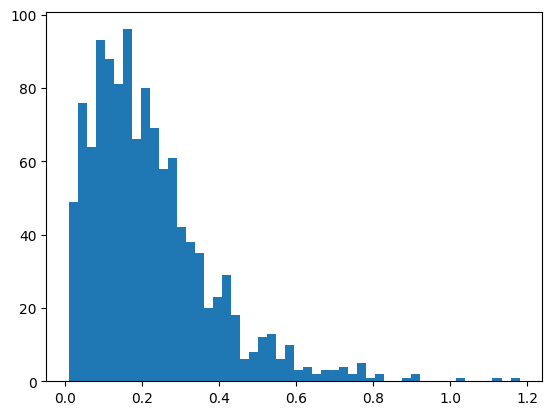

In [62]:
plt.hist(odds, bins=50)
plt.show()

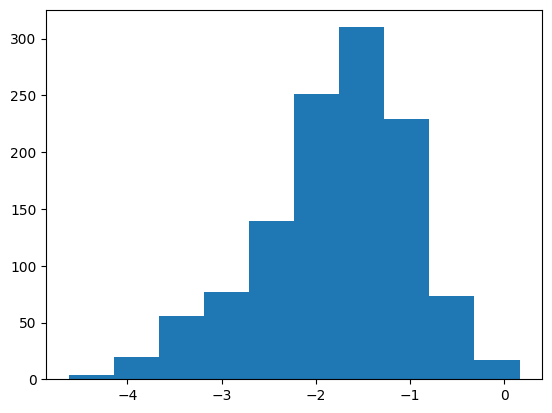

In [63]:
log_odds = np.log(odds)

plt.hist(log_odds)
plt.show()

In [64]:
z = model.intercept_ + (model.coef_ * X_train).sum(axis=1)

In [65]:
data1 = pd.DataFrame({
    'z': z,
    'log_odds': log_odds
})
data1.head()


,z,log_odds
1097,-0.259490,-0.259490
727,-0.419248,-0.419248
254,-1.126230,-1.126230
1175,-1.445438,-1.445438
1341,-1.107189,-1.107189


In [66]:
p = 1 / (1 + np.exp(-z))
probabilidades = model.predict_proba(X_train)

data2 = pd.DataFrame({
    'prob_sklearn': [i[1] for i in probabilidades],
    'prob_sigmoid': p
})
data2.head()

,prob_sklearn,prob_sigmoid
1097,0.435489,0.435489
727,0.396697,0.396697
254,0.244858,0.244858
1175,0.190705,0.190705
1341,0.248395,0.248395


In [67]:
target = 'Attrition'

In [68]:
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

modelo_lineal = model.predict_proba(X_test)

probabilidades_modelo_lineal = [i[1] for i in modelo_lineal]

In [69]:
coeficientes = pd.DataFrame({
    'feature': X_train.keys(),
    'coeficientes': model.coef_[0]
})
coeficientes

,feature,coeficientes
0,Age,-0.032178
1,DailyRate,-0.000288
2,DistanceFromHome,0.035307
3,Education,0.000251
4,EnvironmentSatisfaction,-0.007502
5,HourlyRate,-0.000947
6,JobInvolvement,-0.007255
7,JobLevel,-0.001517
8,MonthlyIncome,-0.000047
9,MonthlyRate,0.000003


In [70]:
coeficientes_ordenados = coeficientes.reindex(coeficientes['coeficientes'].abs().sort_values(ascending=False).index)
coeficientes_ordenados

,feature,coeficientes
2,DistanceFromHome,0.035307
0,Age,-0.032178
20,YearsInCurrentRole,-0.029702
22,YearsWithCurrManager,-0.025078
10,NumCompaniesWorked,0.021699
16,TotalWorkingYears,-0.019107
19,YearsAtCompany,-0.017713
15,StockOptionLevel,-0.011155
44,OverTime_Yes,0.011028
21,YearsSinceLastPromotion,0.009545


**Los coeficientes que tiene más impacto pra predecir si un empleado va a dejar la empresa son los que tiene un valor absoluto mayor. Ya ordenados los coeficnetes, podemos ver que a mayor distancia de casa mayo probabilidad de renunciar. En el caso de la variable edad (que es  negativa) podemos ver que a medida que el empleado crece, más probabilidad hay de que se quede en la empresa. Esto mismo pasa con las variables "YearsInCurrentRole", "YearsWithCurrManager", "TotalWorkingYears", "YearsAtCompany", y "StockOptionLevel" todas estas variables negativas nos dicen que entre más años trabajando, más años en la empresa, más años en ese puesto o con ese jefe el empleado incrementa su probabilidad de quedarse ahí trabajando. En el caso de las variables positivas como la de las personas que hacen overtime, peronas que hace mucho no tienen una promocion, y personas que han trabajdado en más campañías, nos dicen que a medida que cada una de ellas incrementa, entonces la probabilidad de que haya más rotación de personal también sube. Esas son las personas más propensas a cambiar de trabajo."**

Polinomio grado 2

In [72]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=2)),
    ("model", linear_model.LogisticRegression(penalty='l2'))
])

# Entrenar el modelo
pipeline.fit(X_train, y_train)

# Predecir probabilidades
probabilidades_modelo2 = pipeline.predict_proba(X_test)[:, 1]

roc_auc_score(y_score=probabilidades_modelo2, y_true=y_test)

np.float64(0.6881850175967823)

Polinomio grado 3

In [73]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=3)),
    ("model", linear_model.LogisticRegression(penalty='l2'))
])

# Entrenar el modelo
pipeline.fit(X_train, y_train)

# Predecir probabilidades
probabilidades_modelo3 = pipeline.predict_proba(X_test)[:, 1]

roc_auc_score(y_score=probabilidades_modelo3, y_true=y_test)

np.float64(0.7334338863750628)

# Análisis Discriminante Lineal

In [74]:
from sklearn import discriminant_analysis


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", discriminant_analysis.LinearDiscriminantAnalysis())
])

pipeline.fit(X_train, y_train)

probabilidades_discriminante_lineal = pipeline.predict_proba(X_test)[:, 1]

roc_auc_score(y_score=probabilidades_discriminante_lineal, y_true=y_test)

np.float64(0.77114127702363)

In [75]:
calibracion = pd.DataFrame({
    'real': y_test,
    'modelo_lineal': probabilidades_modelo_lineal,
    'modelo_cuadratico': probabilidades_modelo2,
    'modelo_cubico': probabilidades_modelo3,
    'modelo_discriminante_lineal': probabilidades_discriminante_lineal,

})

In [76]:
# Bins
bins = 5
calibracion['bins_lineal'] = pd.qcut(calibracion['modelo_lineal'], q=bins, labels=False) + 1
calibracion['bins_cuadratico'] = pd.qcut(calibracion['modelo_cuadratico'],q=bins, labels=False) + 1
calibracion['bins_cubico'] = pd.qcut(calibracion['modelo_cubico'],q=bins, labels=False) + 1
calibracion['bins_discriminante_lineal'] = pd.qcut(calibracion['modelo_discriminante_lineal'], q=bins, labels=False) + 1

# Agrupaciones
grouped_lineal = calibracion.groupby('bins_lineal').mean()
grouped_cuadratico = calibracion.groupby('bins_cuadratico').mean()
grouped_cubico = calibracion.groupby('bins_cubico').mean()
grouped_discriminante_lineal = calibracion.groupby('bins_discriminante_lineal').mean()


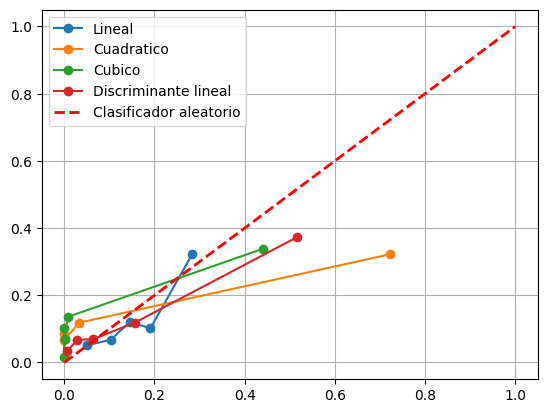

In [77]:
## Grafico de modelos
plt.plot(grouped_lineal.modelo_lineal, grouped_lineal.real, marker="o", label="Lineal")
plt.plot(grouped_cuadratico.modelo_cuadratico, grouped_cuadratico.real, marker="o", label="Cuadratico")
plt.plot(grouped_cubico.modelo_cubico, grouped_cubico.real, marker="o", label="Cubico")
plt.plot(grouped_discriminante_lineal.modelo_discriminante_lineal, grouped_discriminante_lineal.real, marker="o", label="Discriminante lineal")
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.legend()
plt.grid()

**Analizando la gráfica anterior podemos ver como la línea azul que rrepresenta el modelo de regresión logística es la que se acerca más a la linea punteada. Con esto podemos decir que es el modelo que mejor se ajusta. Sin embargo también se podría decir que la linea roja (discriminante lineal) se acera mucho también al modelo perfecto.**

In [78]:
from sklearn.metrics import log_loss, accuracy_score

In [79]:
mod1 = log_loss(y_pred=calibracion.modelo_lineal, y_true=calibracion.real)
mod2 = log_loss(y_pred=calibracion.modelo_cuadratico, y_true=calibracion.real)
mod3 = log_loss(y_pred=calibracion.modelo_cubico, y_true=calibracion.real)
mod4 = log_loss(y_pred=calibracion.modelo_discriminante_lineal, y_true=calibracion.real)

print(mod1, mod2, mod3, mod4)

0.3546157506581598 0.9849797572422615 0.7394265677009788 0.3445393305676116


In [80]:
real1 = calibracion.query("real == 1")
real0 = calibracion.query("real == 0")

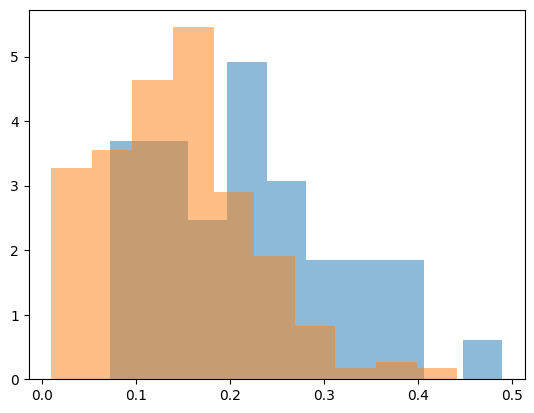

In [81]:
plt.hist(calibracion.modelo_lineal[calibracion.real==1], density=True, alpha=0.5, bins=10)
plt.hist(calibracion.modelo_lineal[calibracion.real==0], density=True, alpha=0.5, bins=10)
plt.show()

**Con esta gráfica podemos confirmar que el modelo de regresión logística sí es el mejor, Es el que tiene un área azul más grande a comparación con las otras gráficas de los otros modelos. Esto significa que este modelo está mejor calibrado y no tiende a subertimar la propabilidad de renuncia como los otros modelos (cuadrático y cúbico).**

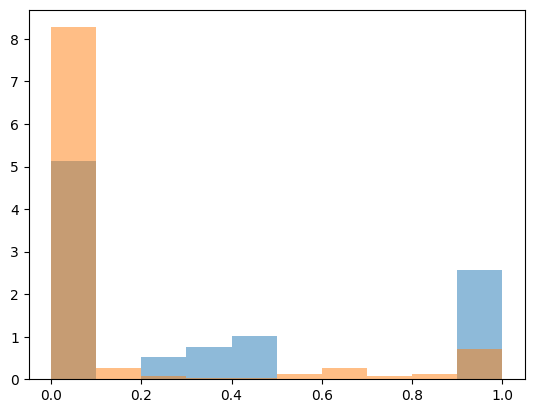

In [82]:
plt.hist(calibracion.modelo_cuadratico[calibracion.real==1], density=True, alpha=0.5, bins=10)
plt.hist(calibracion.modelo_cuadratico[calibracion.real==0], density=True, alpha=0.5, bins=10)
plt.show()

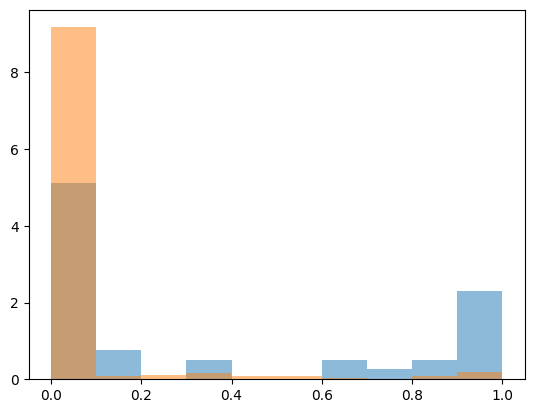

In [83]:
plt.hist(calibracion.modelo_cubico[calibracion.real==1], density=True, alpha=0.5, bins=10)
plt.hist(calibracion.modelo_cubico[calibracion.real==0], density=True, alpha=0.5, bins=10)
plt.show()

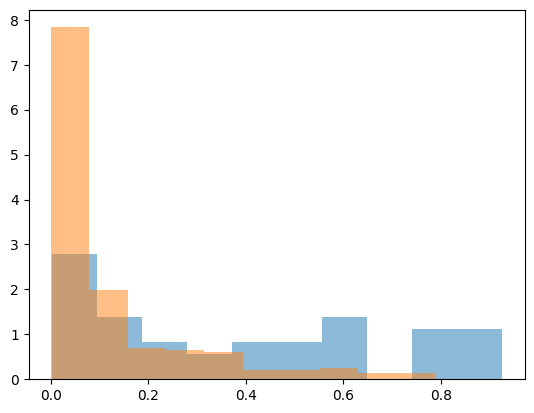

In [84]:
plt.hist(calibracion.modelo_discriminante_lineal[calibracion.real==1], density=True, alpha=0.5, bins=10)
plt.hist(calibracion.modelo_discriminante_lineal[calibracion.real==0], density=True, alpha=0.5, bins=10)
plt.show()

In [88]:
from sklearn.metrics import roc_curve
probabilidades = model.predict_proba(X_test)[:, 1]


fpr, tpr, umbrales = roc_curve(y_true=y_test, y_score=probabilidades)

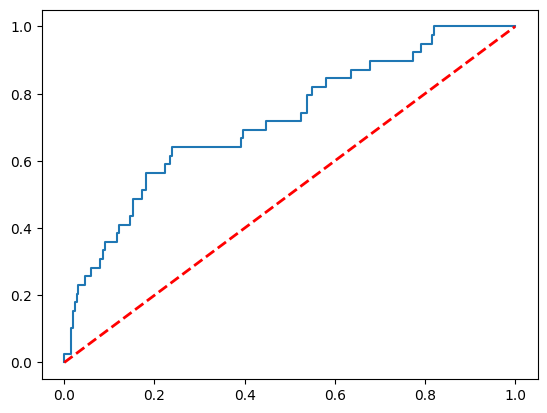

In [89]:
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')

In [90]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_true=y_test, y_score=probabilidades)

np.float64(0.7197586726998493)

In [91]:
fpr2, tpr2, umbrales = roc_curve(y_true=y_test, y_score=probabilidades_modelo2)
fpr3, tpr3, umbrales = roc_curve(y_true=y_test, y_score=probabilidades_modelo3)
fpr4, tpr4, umbrales = roc_curve(y_true=y_test, y_score=probabilidades_discriminante_lineal)

In [118]:
roc_auc_1 = roc_auc_score(y_true=y_test, y_score=probabilidades_modelo_lineal)
roc_auc_2 = roc_auc_score(y_true=y_test, y_score=probabilidades_modelo2)
roc_auc_3 = roc_auc_score(y_true=y_test, y_score=probabilidades_modelo3)
roc_auc_4 = roc_auc_score(y_true=y_test, y_score=probabilidades_discriminante_lineal)

roc_auc_1, roc_auc_2, roc_auc_3, roc_auc_4

(np.float64(0.7197586726998493),
 np.float64(0.6881850175967823),
 np.float64(0.7334338863750628),
 np.float64(0.77114127702363))

**Enfocandonos en el roc_auc score vemos que el mejor modelo es el del discrimante lineal.**

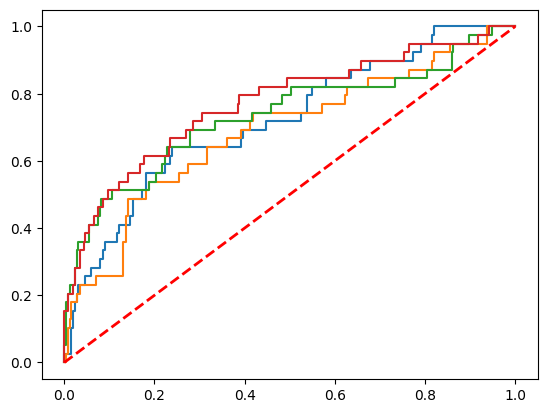

In [92]:
plt.plot(fpr, tpr, label="Lineal")
plt.plot(fpr2, tpr2, label="Cuadratico")
plt.plot(fpr3, tpr3, label="Cubico")
plt.plot(fpr4, tpr4, label="Discriminante lineal")
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')

**Ahora viendo la gráfica del ROC curve podemos ver que la linea azul que representa la regresión logística (modelo lineal) es la que se mantiene más alejada de la recta desde principio a fin. Pero, la que más área tiene según el roc_auc_score es el del modelo de discriminante lineal con un puntaje de 0.7711, visualmente tambien es la que más alejada está de la linea punteada a exepción del final donde se acerca mucho más que la azul. Sin embargo, el puntaje de 0.7711 nos dice que es el modelo más confiable para hacer nuestras predicciones porque tiene mayor capacidad de distinguir entre clases.**

# KNN

In [93]:
from sklearn.neighbors import KNeighborsClassifier
nn = np.linspace(1, 50, 50)
metrics = []
for i in nn:
    pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=int(i))),
    ])

    pipeline.fit(X_train, y_train)

    probabilidades = pipeline.predict_proba(X_test)[:, 1]
    metrics.append(roc_auc_score(y_score=probabilidades, y_true=y_test))

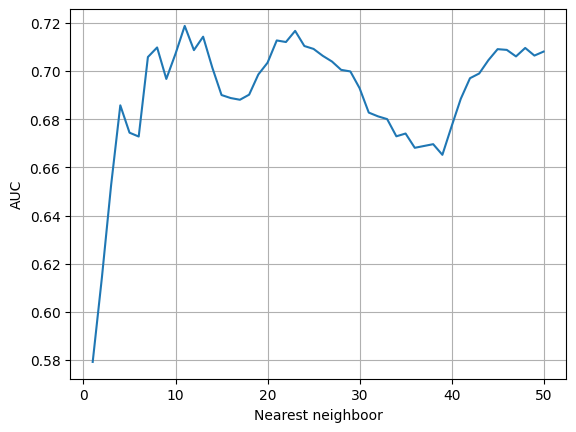

In [94]:
plt.plot(nn, metrics)
plt.xlabel("Nearest neighboor")
plt.ylabel("AUC")
plt.grid()

**Según la gráfica de KNN el número ideal para k es aproximadamente 11, ya que si se aumenta este valor podríamos tener un subajuste, para obtener el mayor AUC posible se debe de mantener k entre 10 y 15.**

# Red neuronal

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn import linear_model

import warnings
warnings.filterwarnings("ignore")

In [99]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [101]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPRegressor())
])

params_grid = {
    'nn__hidden_layer_sizes': [(5,5,5), (10,), (100,), (10,10), (10,10,10), (100,100), (100,100,100)],
    'nn__activation': ['tanh','relu','logistic'],
    'nn__alpha': [0.1,0.01,0.001]
}

grid_nn = GridSearchCV(estimator=pipeline, n_jobs=-1, cv=5, scoring='r2', param_grid=params_grid)

grid_nn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('nn', MLPRegressor())]),
             n_jobs=-1,
             param_grid={'nn__activation': ['tanh', 'relu', 'logistic'],
                         'nn__alpha': [0.1, 0.01, 0.001],
                         'nn__hidden_layer_sizes': [(5, 5, 5), (10,), (100,),
                                                    (10, 10), (10, 10, 10),
                                                    (100, 100),
                                                    (100, 100, 100)]},
             scoring='r2')

In [103]:
grid_nn.best_params_

{'nn__activation': 'logistic',
 'nn__alpha': 0.01,
 'nn__hidden_layer_sizes': (100, 100, 100)}

In [105]:
pred = grid_nn.best_estimator_.predict(X_test)
r2_score(y_pred=pred, y_true=y_test)

0.23450933578754996

In [109]:
def calibracion(predicciones, y, bins):
    df_calibracion = pd.DataFrame({
        'predicciones': predicciones,
        'y': y
    })
    df_calibracion['bins'] = pd.qcut(df_calibracion['predicciones'], q=bins, labels=False, duplicates='drop') + 1
    grouped = df_calibracion.groupby('bins').mean()

    plt.plot(grouped.predicciones, grouped.y, label = 'Modelo', marker = 'o')
    plt.plot(grouped.predicciones, grouped.predicciones, label = 'Real', marker = 'o')
    plt.grid()
    plt.legend()
    plt.xlabel('Predicción')
    plt.ylabel('Real')

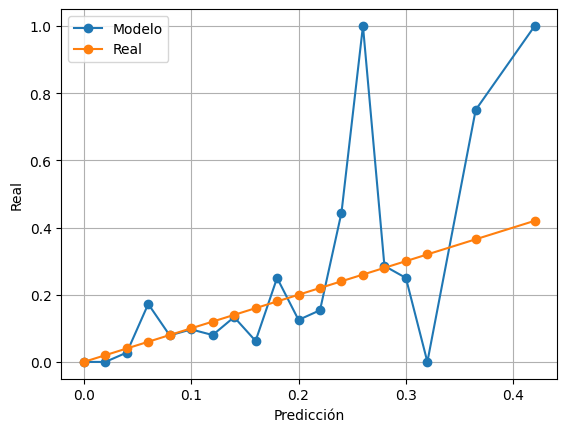

In [114]:
calibracion(probabilidades, y_test, 100)

****En la gráfica podemos ver que hay mucho margen de error y esta no está tan bien ajustada a la realidad. Al mismo tiempo nuestro R^2 es de 23% lo cual tampoco es muy bueno. Podemos ver que hay mucho espacio para mejorar. El mejor parámetro de activación es el de Logistic, en donde utilizamos 3 capas de 100 neuronas cada una.****

# Conclusión final

**Comparando los diferentes modelos para predecir la rotación de empleados, primero observamos que el modelo discriminante lineal obtuvo el mejor desempeño en términos de AUC (0.7711), lo que indica que es el más efectivo para distinguir entre empleados que se quedan y los que renuncian. Sin embargo, el modelo lineal (regresión logística) mostró una mejor calibración, lo cual lo hace más útil cuando se necesita interpretar la probabilidad de renuncia de forma confiable. Por otro lado, el modelo cúbico mejora levemente la capacidad de clasificación, pero no tiene una calibración lo suficientmente buena. En conjunto, el modelo discriminante lineal es el mejor en términos de discriminación, pero el modelo lineal es el más balanceado con su nivel predictivo, su calibración, y estabilidad.**